# <span style="color:blue"> Final Project </span>

Project Name: Pit Stop Strategies 

Members: Jiuyi (Joy) Cheng, Alice Li, Sharon Li, Caroline Zu

## Introduction

Formula 1 (F1) is an international single-seater racing series, where the result is not only determined by the driver, but also by engineers, strategists, and a pit crew. In every Grand Prix, drivers have to make at least one pit stop to change tires, and teams choose when to stop, how many times to stop, and which tires to use. For our project, we want to explore whether pit stop strategies actually decide race outcomes, and identify drivers that are consistently helped or hurt by them. Using F1 data, we focus on how pit stop duration and timing relate to position changes and points scored. This is worthy to explore because fans often say races are “won in the pits,” but those claims are usually based on a few dramatic moments rather than systematic evidence.

Specifically, we combine the pit_stops, results, driver, and constructor tables to establish a relationship between each driver’s pit stop history to their race outcomes. By splitting our research question into smaller sub-questions, we start by looking at how average pit stop time and number of stops correlate with changes from grid position to final position. Then, we examine which drivers gain or lose the most places after pit stops. On top of this, we then explore the performance of constructors in the pits across seasons (whether or not “teams” behind the driver make a systematic impact). We end by discussing what these patterns suggest about the impact of the pit-stop strategy. 

The main goal of the project is ... 



The first paragraph should briefly describe what the topic is, what data analysis
question you’re interested in, and why it is relevant. The introduction should end
with a high-level description of the results and the coming structure of the project. 

### Research Question: How do Formula 1 teams adopt pit stop strategies to impact race outcomes? 

## Data Description

Write a markdown chunk of 1 paragraph describing which dataset tables (among the multiple options) you will be using. State what each row represents, how many observations are contained in each table, and a brief overview of the of
the data that is contained there:

▪ Import any necessary libraries.
▪ Import the data.
▪ Do any calculations for counting the number of rows, etc.

In [50]:
# Import relevant libraries
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [51]:
# Import relevant data files
files = [
    "circuits", "constructors", "drivers", "lap_times", 
    "pit_stops", "qualifying", "races", "results"
]

data = {f: pd.read_csv(f"1-Formula_One/{f}.csv") for f in files}

# Display basic info such dimensions 
for name, df in data.items():
    print(f"{name}: {df.shape}")
    # display(df.head())

circuits: (76, 9)
constructors: (211, 5)
drivers: (854, 9)
lap_times: (528785, 6)
pit_stops: (9299, 7)
qualifying: (9395, 9)
races: (1079, 18)
results: (25660, 18)


### Data Processing

In [52]:
# Pit stop aggregation per driver per race
pit_agg = (
    data['pit_stops']
    .groupby(['raceId','driverId'], as_index=False)
    .agg(
        pit_count=('stop','count'),
        avg_pit_duration=('milliseconds','mean')
    )
)

# Define a function to help merging dataframes
def merge_info(df, key, info_df, columns, rename_dict=None):
    temp = info_df[columns]
    if rename_dict:
        temp = temp.rename(columns=rename_dict)
    return df.merge(temp, on=key, how='left')

# Start from results
df = data['results'].copy()

# Merge pit stop info
df = merge_info(
    df, ['raceId','driverId'],
    pit_agg, ['raceId','driverId','pit_count','avg_pit_duration']
)

# Merge driver info
df = merge_info(
    df, 'driverId',
    data['drivers'], ['driverId','forename','surname','nationality']
)
df['driver_name'] = df['forename'] + ' ' + df['surname']

# Merge constructor info
df = merge_info(
    df, 'constructorId',
    data['constructors'], ['constructorId','name'], {'name':'constructor'}
)

# Merge qualifying grid (for Q1 regression)
df = merge_info(
    df, ['raceId','driverId'],
    data['qualifying'], ['raceId','driverId','position'], {'position':'grid_position'}
)

# Merge race info (optional if needed for Q2/Q3)
df = merge_info(
    df, 'raceId',
    data['races'], ['raceId','year','round','circuitId','name']
)

# Merge circuit info (optional)
df = merge_info(
    df, 'circuitId',
    data['circuits'], ['circuitId','location','country']
)

# Final cleaned df_formula1
df_formula1 = df[[
    'raceId','year','round','name','location','country',
    'driverId','driver_name','nationality',
    'constructorId','constructor',
    'grid_position','positionOrder','points','laps','statusId',
    'pit_count','avg_pit_duration'
]].copy()

# Fill missing pit info with 0
df_formula1[['pit_count','avg_pit_duration']] = df_formula1[['pit_count','avg_pit_duration']].fillna(0)

# Fill missing grid positions with max + 1 
max_grid = df_formula1['grid_position'].max(skipna=True)
df_formula1['grid_position'] = df_formula1['grid_position'].fillna(max_grid + 1)

display(df_formula1)
print(df_formula1.shape)

,raceId,year,round,name,location,country,driverId,driver_name,nationality,constructorId,constructor,grid_position,positionOrder,points,laps,statusId,pit_count,avg_pit_duration
0,18,2008,1,Australian Grand Prix,Melbourne,Australia,1,Lewis Hamilton,British,1,McLaren,1.0,1,10.0,58,1,0.0,0.000000
1,18,2008,1,Australian Grand Prix,Melbourne,Australia,2,Nick Heidfeld,German,2,BMW Sauber,5.0,2,8.0,58,1,0.0,0.000000
2,18,2008,1,Australian Grand Prix,Melbourne,Australia,3,Nico Rosberg,German,3,Williams,7.0,3,6.0,58,1,0.0,0.000000
3,18,2008,1,Australian Grand Prix,Melbourne,Australia,4,Fernando Alonso,Spanish,4,Renault,12.0,4,5.0,58,1,0.0,0.000000
4,18,2008,1,Australian Grand Prix,Melbourne,Australia,5,Heikki Kovalainen,Finnish,1,McLaren,3.0,5,4.0,58,1,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,1086,2022,13,Hungarian Grand Prix,Budapest,Hungary,825,Kevin Magnussen,Danish,210,Haas F1 Team,13.0,16,0.0,69,11,3.0,25332.666667
25656,1086,2022,13,Hungarian Grand Prix,Budapest,Hungary,848,Alexander Albon,Thai,3,Williams,17.0,17,0.0,69,11,3.0,25779.333333
25657,1086,2022,13,Hungarian Grand Prix,Budapest,Hungary,849,Nicholas Latifi,Canadian,3,Williams,20.0,18,0.0,69,11,3.0,24364.666667
25658,1086,2022,13,Hungarian Grand Prix,Budapest,Hungary,852,Yuki Tsunoda,Japanese,213,AlphaTauri,16.0,19,0.0,68,12,3.0,21907.000000


(25660, 18)


### Visualization

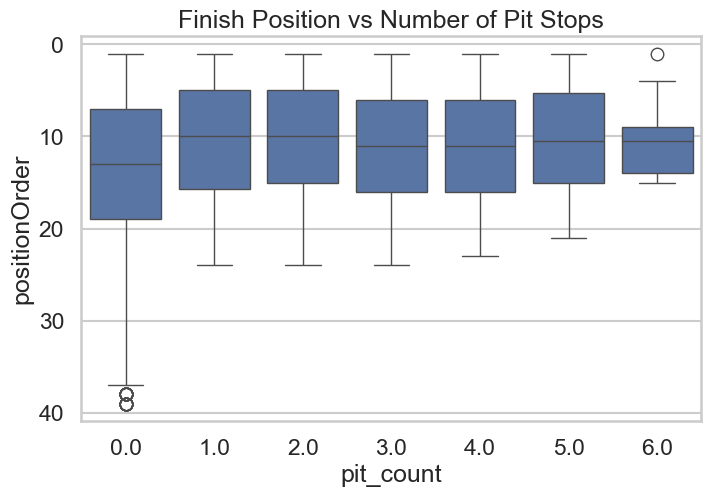

In [66]:
# Pit stops vs finish position
plt.figure(figsize=(8,5))
sns.boxplot(x='pit_count', y='positionOrder', data=df_formula1)
plt.title("Finish Position vs Number of Pit Stops")
plt.gca().invert_yaxis()  # 1st place at top
plt.show()

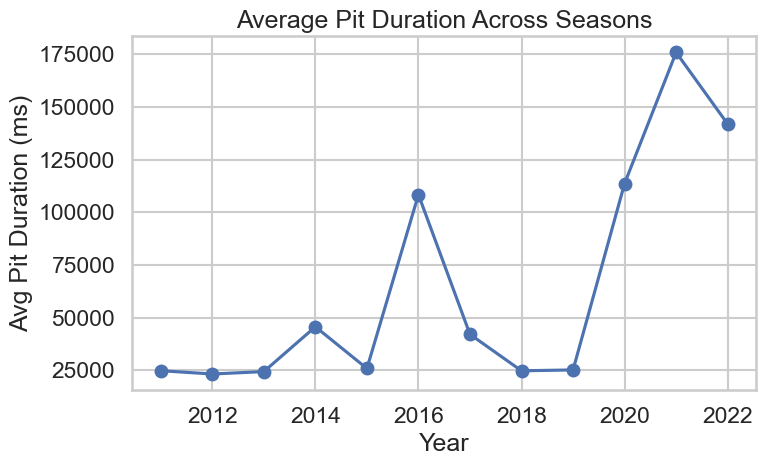

In [67]:
yearly_pit = (
    df.groupby("year")["avg_pit_duration"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.plot(
    yearly_pit["year"],
    yearly_pit["avg_pit_duration"],
    marker="o"
)
plt.title("Average Pit Duration Across Seasons")
plt.xlabel("Year")
plt.ylabel("Avg Pit Duration (ms)")
plt.tight_layout()
plt.show()

### Q1: How much do pit stop strategies change a driver’s expected finishing position?

In [56]:
model = smf.ols(
    "positionOrder ~ pit_count + avg_pit_duration + grid_position", 
    data=df_formula1
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     612.4
Date:                Mon, 01 Dec 2025   Prob (F-statistic):               0.00
Time:                        11:42:49   Log-Likelihood:                -87972.
No. Observations:               25660   AIC:                         1.760e+05
Df Residuals:                   25656   BIC:                         1.760e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            8.0217      0.149  

In [68]:
df_formula1['predicted'] = model.predict(df_formula1)
df_formula1['residual'] = df_formula1['predicted'] - df_formula1['positionOrder']

driver_effects = (
    df_formula1.groupby('driverId')['residual']
    .mean()
    .reset_index()
    .merge(data['drivers'][['driverId','forename','surname']], on='driverId')
    .dropna(subset=['residual'])
)
print("Drivers Most Helped by Pit Strategy")
display(driver_effects.sort_values('residual').head(10))

print("Drivers Most Hurt by Pit Strategy")
display(driver_effects.sort_values('residual').tail(10))

Drivers Most Helped by Pit Strategy


,driverId,residual,forename,surname
133,134,-24.561289,Enrico,Bertaggia
491,492,-23.727956,Menato,Boffa
163,164,-22.299384,Joachim,Winkelhock
265,266,-20.727956,Brian,McGuire
160,161,-20.427956,Volker,Weidler
149,150,-20.227956,Gary,Brabham
717,718,-19.727956,Ernst,Loof
759,760,-19.727956,Piero,Dusio
141,142,-19.343340,Pedro,Chaves
262,263,-19.227956,Mikko,Kozarowitzky


Drivers Most Hurt by Pit Strategy


,driverId,residual,forename,surname
805,806,8.272044,Óscar,González
641,642,8.434207,Nino,Farina
793,794,9.272044,Joie,Chitwood
694,695,9.272044,Oscar,Gálvez
742,743,9.272044,Eric,Thompson
578,579,9.478941,Juan,Fangio
785,786,9.897044,Luigi,Fagioli
765,766,10.772044,Lee,Wallard
590,591,12.272044,George,Amick
801,802,12.272044,Dorino,Serafini


/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_99097/3045105598.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_99097/3045105598.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


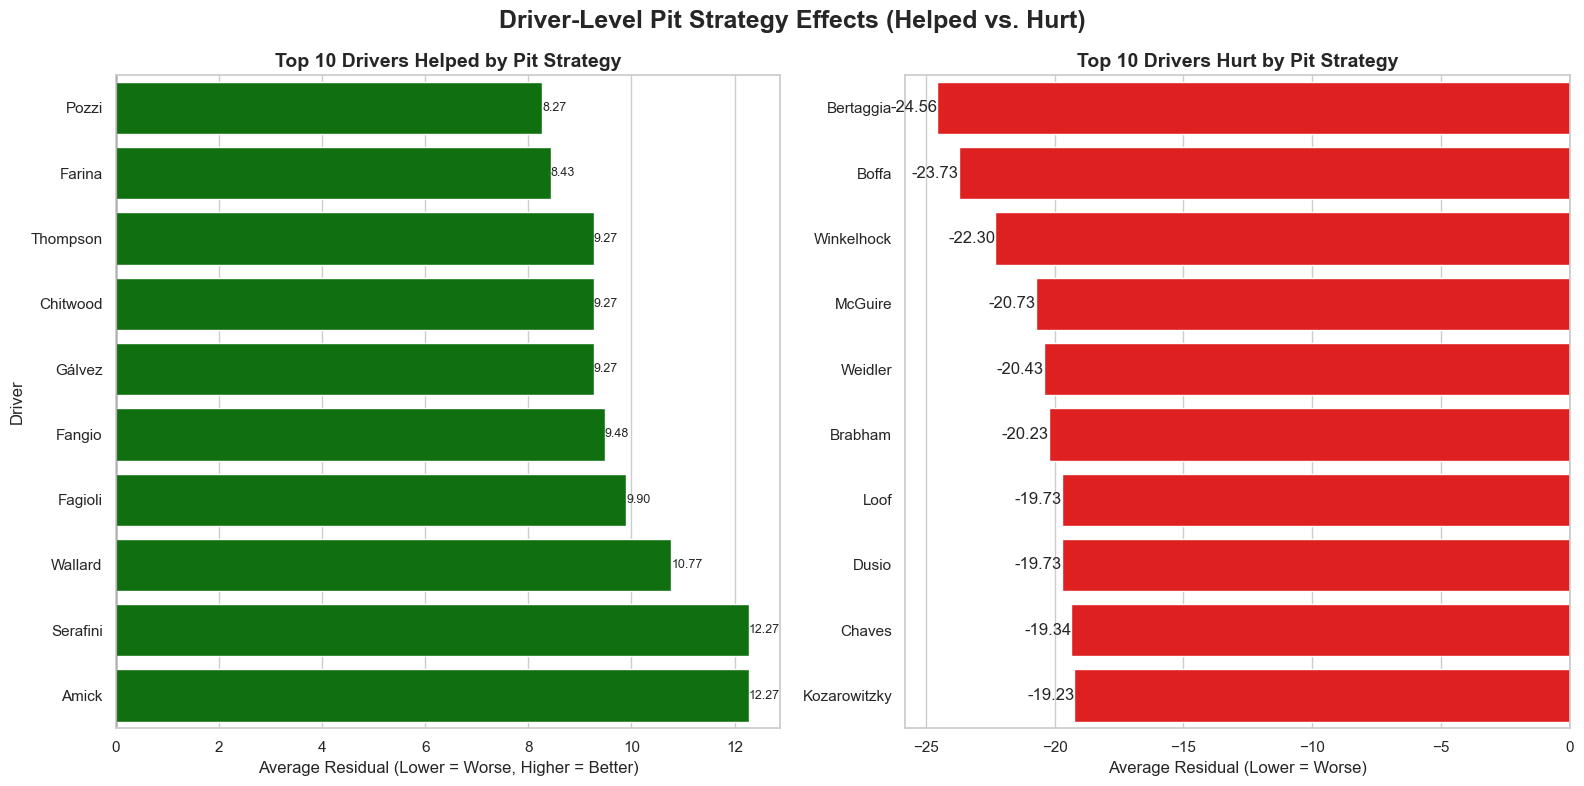

In [ ]:
# Set style
sns.set(style="whitegrid")

# Prepare top 10 helped and top 10 hurt
top_helped = driver_effects.sort_values("residual", ascending=False).head(10)
top_hurt   = driver_effects.sort_values("residual", ascending=True).head(10)

# Combined figure
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=False)

# ---------------------------------------------------------
# LEFT: Top 10 Helped
# ---------------------------------------------------------
sns.barplot(
    ax=axes[0],
    x="residual",
    y="surname",
    data=top_helped.sort_values("residual"),
    palette=["green"] * len(top_helped)  # green theme
)

axes[0].set_title("Top 10 Drivers Helped by Pit Strategy", fontsize=14, weight='bold')
axes[0].set_xlabel("Average Residual (Lower = Worse, Higher = Better)")
axes[0].set_ylabel("Driver")
axes[0].axvline(0, color="black", linewidth=1)

for i, v in enumerate(top_helped.sort_values("residual")["residual"]):
    axes[0].text(v + 0.001, i, f"{v:.2f}", va='center', fontsize=9)

# ---------------------------------------------------------
# RIGHT: Top 10 Hurt
# ---------------------------------------------------------
sns.barplot(
    ax=axes[1],
    x="residual",
    y="surname",
    data=top_hurt.sort_values("residual"),
    palette=["red"] * len(top_hurt)  # red theme
)

axes[1].set_title("Top 10 Drivers Hurt by Pit Strategy", fontsize=14, weight='bold')
axes[1].set_xlabel("Average Residual (Lower = Worse)")
axes[1].set_ylabel("")
axes[1].axvline(0, color="black", linewidth=1)

for i, v in enumerate(top_hurt.sort_values("residual")["residual"]):
    axes[1].text(v - 0.001, i, f"{v:.2f}", va='center', ha='right', fontsize=12)

# Final Layout
plt.suptitle("Driver-Level Pit Strategy Effects (Helped vs. Hurt)", fontsize=18, weight='bold')
plt.tight_layout()  # spacing for suptitle

plt.show()

Positive residual → finishes better than predicted (pit stops helped).

Negative residual → finishes worse than predicted (pit stops hurt).

### Question 2: When do pit stops generate the highest net position gains (early, mid, late)?

position gain = position before pit − position after pit

In [70]:
# Align positions before/after pit
pit_with_positions = data['pit_stops'].merge(
    data['lap_times'][['raceId','driverId','lap','position']],
    on=['raceId','driverId','lap'],
    how='left'
).rename(columns={'position':'position_after_pit'})

pit_with_positions = pit_with_positions.merge(
    data['lap_times'].assign(lap=lambda x: x.lap+1)[['raceId','driverId','lap','position']],
    on=['raceId','driverId','lap'],
    how='left'
).rename(columns={'position':'position_before_pit'})

pit_with_positions['position_gain'] = pit_with_positions['position_before_pit'] - pit_with_positions['position_after_pit']

# Compute pit stage
race_laps = data['results'].groupby('raceId')['laps'].max().reset_index().rename(columns={'laps':'total_laps'})
pit_with_positions = pit_with_positions.merge(race_laps, on='raceId')
pit_with_positions['pit_pct'] = pit_with_positions['lap'] / pit_with_positions['total_laps']

pit_with_positions['pit_stage'] = pd.cut(
    pit_with_positions['pit_pct'],
    bins=[0,0.33,0.66,1],
    labels=['early','mid','late']
)

stage_gain = pit_with_positions.groupby('pit_stage')['position_gain'].mean().reset_index()
print("=== Average Position Gain by Pit Stage ===")
display(stage_gain)

=== Average Position Gain by Pit Stage ===


/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_99097/588310917.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stage_gain = pit_with_positions.groupby('pit_stage')['position_gain'].mean().reset_index()


,pit_stage,position_gain
0,early,-1.022734
1,mid,-0.803612
2,late,-0.527962


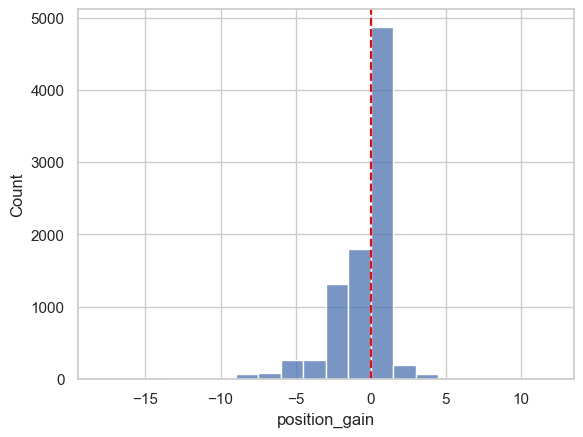

In [60]:
pit_with_positions['position_gain'].describe()
sns.histplot(pit_with_positions['position_gain'], bins=20)
plt.axvline(0, color='red', linestyle='--')
plt.show()

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_99097/2076263307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pit_with_positions, x='pit_stage', y='position_gain', palette='Set2')


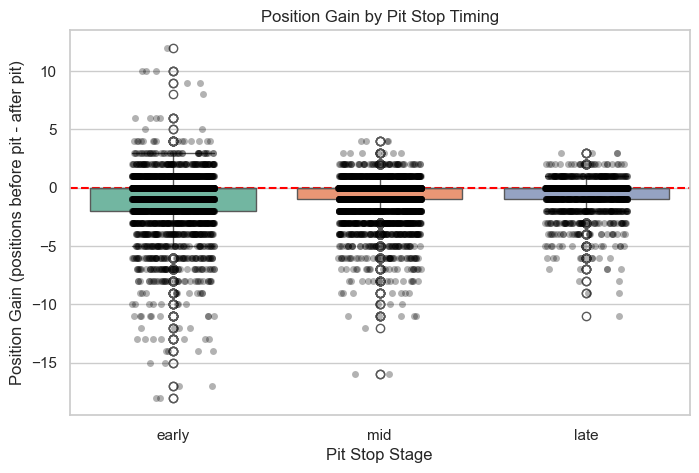

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(data=pit_with_positions, x='pit_stage', y='position_gain', palette='Set2')
sns.stripplot(data=pit_with_positions, x='pit_stage', y='position_gain', color='black', alpha=0.3, jitter=0.2)
plt.title("Position Gain by Pit Stop Timing")
plt.ylabel("Position Gain (positions before pit - after pit)")
plt.xlabel("Pit Stop Stage")
plt.axhline(0, color='red', linestyle='--', label='No Gain/Loss')
plt.show()

### Question 3: Which constructors consistently outperform others in pit stop efficiency?

In [72]:
pit_constructor = data['pit_stops'].merge(
    data['results'][['raceId','driverId','constructorId','positionOrder','points']],
    on=['raceId','driverId']
)

constructor_pit_eff = pit_constructor.groupby('constructorId').agg(
    avg_pit_duration=('milliseconds','mean'),
    total_stops=('stop','count')
).reset_index().merge(
    data['constructors'][['constructorId','name']].rename(columns={'name':'constructor'}),
    on='constructorId'
)

team_perf = data['results'].groupby('constructorId').agg(
    avg_finish=('positionOrder','mean'),
    total_points=('points','sum')
).reset_index()

constructor_perf = constructor_pit_eff.merge(team_perf, on='constructorId')
corr = constructor_perf[['avg_pit_duration','avg_finish']].corr().iloc[0,1]
print(f"Correlation between pit duration and finishing position: {corr:.3f}")

print("=== Top 10 Constructors by Pit Efficiency ===")
display(constructor_perf.sort_values('avg_pit_duration').head(10))
print("=== Bottom 10 Constructors by Pit Efficiency ===")
display(constructor_perf.sort_values('avg_pit_duration').tail(10))

Correlation between pit duration and finishing position: -0.363
=== Top 10 Constructors by Pit Efficiency ===


,constructorId,avg_pit_duration,total_stops,constructor,avg_finish,total_points
12,166,24236.194805,77,Virgin,19.000000,0.0
13,205,24444.211765,85,Lotus,17.973684,0.0
16,208,32463.750877,285,Lotus F1,11.311688,706.0
11,164,32677.766667,150,HRT,19.853448,0.0
15,207,33924.618257,241,Caterham,17.464286,0.0
14,206,34396.836910,233,Marussia,17.642202,2.0
3,5,44486.983895,683,Toro Rosso,13.494403,500.0
7,15,44546.524960,621,Sauber,12.901141,557.0
6,10,50845.770115,609,Force India,11.686321,1098.0
2,4,63261.833747,403,Renault,11.168996,1777.0


=== Bottom 10 Constructors by Pit Efficiency ===


,constructorId,avg_pit_duration,total_stops,constructor,avg_finish,total_points
4,6,74682.195506,890,Ferrari,8.364105,9924.27
10,131,75670.788889,900,Mercedes,5.789668,6726.64
0,1,77249.898075,883,McLaren,9.612245,6085.50
17,209,84025.750000,156,Manor Marussia,16.923077,1.00
18,210,102017.145336,461,Haas F1 Team,14.370370,231.00
19,211,104668.644068,118,Racing Point,10.631579,283.00
8,51,150177.350598,251,Alfa Romeo,13.293059,341.00
20,213,206209.518519,189,AlphaTauri,11.663462,276.00
9,117,207027.690476,126,Aston Martin,12.148148,97.00
21,214,230621.220339,118,Alpine F1 Team,9.971429,251.00


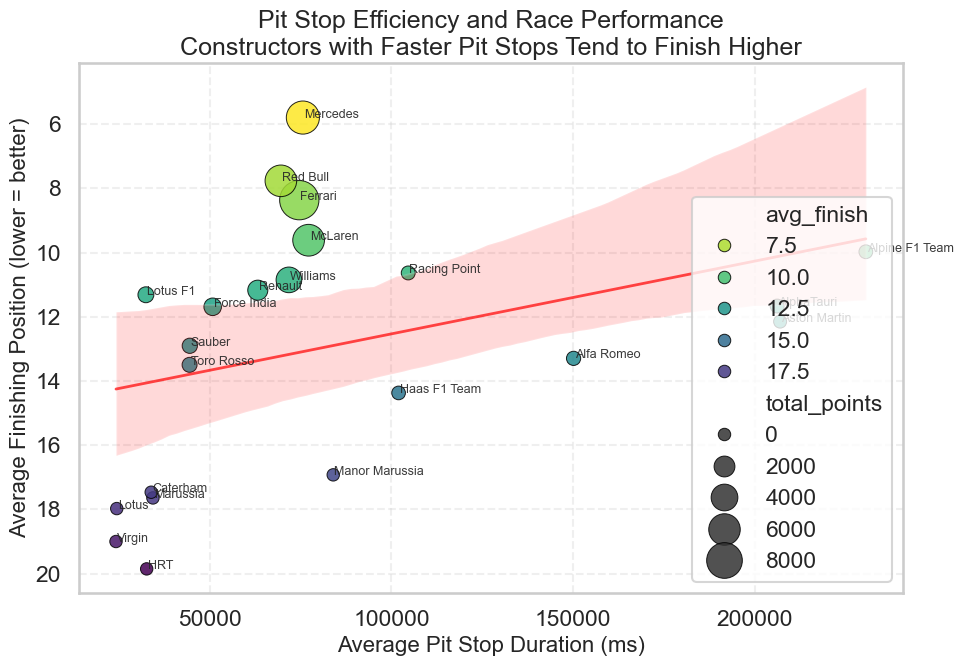

In [74]:
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(10,7))

# Scatter plot: performance vs pit efficiency
scatter = sns.scatterplot(
    data=constructor_perf,
    x='avg_pit_duration',
    y='avg_finish',
    size='total_points',
    sizes=(80, 800),
    hue='avg_finish',                # continuous color scale
    palette='viridis_r',
    alpha=0.85,
    edgecolor='black'
)

# Trend line (OLS)
sns.regplot(
    data=constructor_perf,
    x='avg_pit_duration',
    y='avg_finish',
    scatter=False,
    color='red',
    line_kws={"linewidth": 2, "alpha": 0.7}
)

# Add constructor labels directly to points
for i, row in constructor_perf.iterrows():
    plt.text(
        row['avg_pit_duration'] + 300,     # nudge label right
        row['avg_finish'],
        row['constructor'],
        fontsize=9,
        alpha=0.9
    )

# Titles and labels
plt.title(
    "Pit Stop Efficiency and Race Performance\n"
    "Constructors with Faster Pit Stops Tend to Finish Higher")

plt.xlabel("Average Pit Stop Duration (ms)", fontsize=16)
plt.ylabel("Average Finishing Position (lower = better)", fontsize=16)

# Invert y-axis (1st is at the top)
plt.gca().invert_yaxis()

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



o Write a paragraph in markdown describing any merging procedures:
▪ Include code for merging.
o Write a paragraph in markdown summarizing data cleaning procedures:
▪ Include code for data cleaning.
o Write a paragraph describing your main columns:
▪ Compute a table of descriptive statistics for the main columns of the
merged dataset that you’re interested. Try to be selective. The idea is to
do a deeper analysis of a few columns rather than to do a lot.


### Results 

o This should contain a combination of code to produce tables/plots and
markdown text explaining what the findings are.
o Be creative! The idea is to understand the relationship between different sets of
columns to answer an interesting question about the data.

### Discussion:

Provide a brief 1 paragraph markdown chunk summarizing your findings.
Describe the main things you learned from the data.